# Group Pipeline — Comparison of All 6 Preprocessing Techniques
**IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)**

## 1. Introduction

This notebook does **NOT** chain the 6 members' preprocessing notebooks together — it simply
**loads and compares** the 6 independently-produced output files. Run this notebook **last**,
after all 6 member notebooks (`IT0001`-`IT0006`) have been run at least once and their outputs
exist in `results/outputs/`.

## 2. Load All 6 Outputs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

files = {
    'Label Encoding': 'results/outputs/step_M1_label_encoded.csv',
    'One-Hot Encoding': 'results/outputs/step_M2_onehot_encoded.csv',
    'Ordinal + Imputation': 'results/outputs/step_M3_ordinal_encoded.csv',
    'Binary Encoding': 'results/outputs/step_M4_binary_encoded.csv',
    'Chi-Square Selected': 'results/outputs/step_M5_chi2_selected.csv',
    'Target/Frequency Encoding': 'results/outputs/step_M6_target_freq_encoded.csv',
}

missing = [name for name, path in files.items() if not os.path.exists(path)]
if missing:
    print("WARNING — these member outputs are missing, run their notebooks first:")
    for name in missing:
        print(" -", name, files[name])
else:
    print("All 6 member outputs found.")

dfs = {name: pd.read_csv(path) for name, path in files.items() if os.path.exists(path)}
for name, d in dfs.items():
    print(f"{name}: {d.shape}")

All 6 member outputs found.
Label Encoding: (8124, 22)
One-Hot Encoding: (8124, 95)
Ordinal + Imputation: (8124, 22)
Binary Encoding: (8124, 64)
Chi-Square Selected: (8124, 11)
Target/Frequency Encoding: (8124, 22)


## 3. Compare Shapes and Techniques

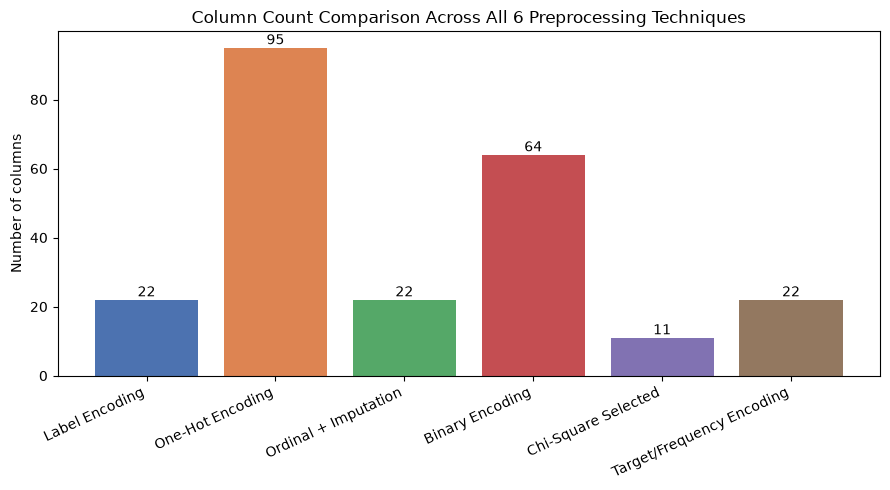

In [2]:
os.makedirs('results/eda_visualizations', exist_ok=True)

names = list(dfs.keys())
col_counts = [dfs[n].shape[1] for n in names]

plt.figure(figsize=(9, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
bars = plt.bar(names, col_counts, color=colors[:len(names)])
plt.ylabel('Number of columns')
plt.title('Column Count Comparison Across All 6 Preprocessing Techniques')
plt.xticks(rotation=25, ha='right')
for bar, v in zip(bars, col_counts):
    plt.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center')
plt.tight_layout()
plt.savefig('results/eda_visualizations/GROUP_shape_comparison.png', dpi=150)
plt.show()

## 4. Recommend Technique per Model

| Model | Recommended Preprocessing Output | Reason |
|---|---|---|
| Logistic Regression | One-Hot Encoding | No false ordinal assumptions; linear models need each category as an independent binary input. |
| Decision Tree | Label Encoding | Tree splits on thresholds, so integer codes work fine and keep the column count small. |
| Random Forest | Ordinal + Imputation | Tree ensembles handle ordinal encoding well and benefit from KNN-imputed missing values. |
| SVM | Binary Encoding | Keeps dimensionality moderate (unlike one-hot) while avoiding a false linear ordering, which matters for kernel/distance computations. |
| KNN | Chi-Square Selected | KNN is distance-based and suffers in high-dimensional/sparse spaces (like one-hot); a smaller, most-informative feature set improves distance meaningfulness. |
| Neural Network | One-Hot Encoding | NNs can learn from independent binary inputs efficiently and don't assume ordinality; extra dimensionality is manageable via the network's hidden layers. |


## 5. Train/Test Split for Each Recommended Pairing

In [3]:
from sklearn.model_selection import train_test_split

recommendations = {
    'logisticregression': ('One-Hot Encoding', 'onehot'),
    'decisiontree': ('Label Encoding', 'labelenc'),
    'randomforest': ('Ordinal + Imputation', 'ordinal'),
    'svm': ('Binary Encoding', 'binary'),
    'knn': ('Chi-Square Selected', 'chi2'),
    'neuralnetwork': ('One-Hot Encoding', 'onehot'),
}

os.makedirs('results/outputs', exist_ok=True)
splits_done = set()

for model_name, (source_name, short_tag) in recommendations.items():
    if source_name not in dfs:
        print(f"Skipping {model_name}: '{source_name}' output not loaded.")
        continue
    if short_tag in splits_done:
        # Already produced this split for a previous model that shares the same source
        print(f"{model_name}: reusing existing split files for '{short_tag}' ({source_name})")
        continue

    data = dfs[source_name]
    X = data.drop(columns=['class'])
    y = data['class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train.to_csv(f'results/outputs/X_train_{short_tag}.csv', index=False)
    X_test.to_csv(f'results/outputs/X_test_{short_tag}.csv', index=False)
    y_train.to_csv(f'results/outputs/y_train_{short_tag}.csv', index=False)
    y_test.to_csv(f'results/outputs/y_test_{short_tag}.csv', index=False)

    print(f"{model_name} <- {source_name}: "
          f"X_train {X_train.shape}, X_test {X_test.shape}")
    splits_done.add(short_tag)

print()
print("All recommended train/test splits saved to results/outputs/")

logisticregression <- One-Hot Encoding: X_train (6499, 94), X_test (1625, 94)
decisiontree <- Label Encoding: X_train (6499, 21), X_test (1625, 21)
randomforest: reusing existing split files for 'labelenc' (Label Encoding)
svm <- Binary Encoding: X_train (6499, 63), X_test (1625, 63)
knn <- Chi-Square Selected: X_train (6499, 10), X_test (1625, 10)
neuralnetwork: reusing existing split files for 'onehot' (One-Hot Encoding)

All recommended train/test splits saved to results/outputs/
